In [1]:
import uproot
import pandas as pd
import awkward as ak
import matplotlib.pyplot as plt

tables_qvec = [
    "O2qvectordevs",
    "O2qvectorsft0c",
    "O2qvectorsft0a",
    "O2qvectorsft0m",
    "O2qvectorsfv0a",
    "O2qvectorstpcpos",
    "O2qvectorstpcneg",
    "O2qvectorstpcall",
    "O2qvectorsft0cvec",
    "O2qvectorsft0avec",
    "O2qvectorsft0mvec",
    "O2qvectorsfv0avec",
    "O2qvectorstpcpvec",
    "O2qvectorstpcnvec",
    "O2qvectorstpcavec"
]

tables_ese = [
    "O2eseqvectordevs",
    "O2eseqvecft0c",
    "O2eseqvecft0a",
    "O2eseqvecft0m",
    "O2eseqvecfv0a",
    "O2eseqvectpcpos",
    "O2eseqvectpcneg",
    "O2eseqvectpcall",
    "O2eseqvecft0cvec",
    "O2eseqvecft0avec",
    "O2eseqvecft0mvec",
    "O2eseqvecfv0avec",
    "O2eseqvectpcpvec",
    "O2eseqvectpcnvec",
    "O2eseqvectpcavec",
    "O2eseqvecperc"
]

import uproot
import pandas as pd
import awkward as ak


def load_tables(filename, tables):
    data_dict = {}

    with uproot.open(filename) as f:
        keys = f.keys()
        print(f"Keys in {filename}: {keys}")

        for table in tables:
            matched_keys = [
                key for key in keys
                if len(key.split("/")) == 2
                and key.split("/")[1].split(";")[0] == table
            ]
            # matched_keys = [key for key in keys if table == key.split("/")[1].replace(";1", "") and len(key.split("/")) == 2]
            # matched_keys = [key for key in keys if table in key]

            if not matched_keys:
                print(f"No keys found for table: {table}")
                continue

            table_dfs = []

            for key in matched_keys:
                array = f[key].arrays(library="ak")

                if len(array) == 0:
                    print(f"Empty array for key: {key}")
                    continue

                data = {}
                for k in array.fields:
                    v = array[k]
                    
                    if isinstance(ak.type(v).content, ak.types.NumpyType):
                        # scalar branch
                        data[k] = ak.to_numpy(v)
                    else:
                        # vector branch
                        data[k] = ak.to_list(v)

                df = pd.DataFrame(data)

                # df = pd.DataFrame({
                #     k: ak.to_list(array[k]) if ak.ndim(array[k]) > 1 else ak.to_numpy(array[k])
                #     for k in array.fields
                # })
                # df = pd.DataFrame({k: ak.to_list(v) for k, v in array.items()})
                # df = ak.to_dataframe(array)

                if df.empty:
                    print(f"Empty DataFrame for key: {key}")
                    continue

                # optional but VERY useful: avoid duplicate column collisions
                df = df.add_prefix(f"{table}__")

                table_dfs.append(df)

            if table_dfs:
                data_dict[table] = pd.concat(table_dfs, ignore_index=True)
            else:
                print(f"No usable data for table: {table}")

    return data_dict


# Load datasets
df_before_mod = load_tables("/home/mdicosta/LocalTestsO2/ReducedQvectors/BeforeModifications/Tree_2nd_3rd_harm.root", tables_qvec)
df_after_mod  = load_tables("Tree.root", tables_qvec)
df_after_mod_with_ese  = load_tables("Tree.root", tables_ese)

Keys in /home/mdicosta/LocalTestsO2/ReducedQvectors/BeforeModifications/Tree_2nd_3rd_harm.root: ['DF_2337256861756704;1', 'DF_2337256861756704/O2qvectordevs;1', 'DF_2337256861756704/O2qvectorsft0a;1', 'DF_2337256861756704/O2qvectorsft0avec;1', 'DF_2337256861756704/O2qvectorsft0c;1', 'DF_2337256861756704/O2qvectorsft0cvec;1', 'DF_2337256861756704/O2qvectorsft0m;1', 'DF_2337256861756704/O2qvectorsft0mvec;1', 'DF_2337256861756704/O2qvectorsfv0a;1', 'DF_2337256861756704/O2qvectorsfv0avec;1', 'DF_2337256861756704/O2qvectorstpcall;1', 'DF_2337256861756704/O2qvectorstpcavec;1', 'DF_2337256861756704/O2qvectorstpcneg;1', 'DF_2337256861756704/O2qvectorstpcnvec;1', 'DF_2337256861756704/O2qvectorstpcpos;1', 'DF_2337256861756704/O2qvectorstpcpvec;1', 'parentFiles;1']
Empty array for key: DF_2337256861756704/O2qvectorstpcpos;1
No usable data for table: O2qvectorstpcpos
Empty array for key: DF_2337256861756704/O2qvectorstpcneg;1
No usable data for table: O2qvectorstpcneg
Empty array for key: DF_23372

In [2]:
print("Data loaded successfully.")
print(f"keys df_before_mod: {df_before_mod.keys()}")
print(f"keys df_after_mod: {df_after_mod.keys()}")

Data loaded successfully.
keys df_before_mod: dict_keys(['O2qvectordevs', 'O2qvectorsft0c', 'O2qvectorsft0a', 'O2qvectorsft0m', 'O2qvectorsfv0a', 'O2qvectorsft0cvec', 'O2qvectorsft0avec', 'O2qvectorsft0mvec', 'O2qvectorsfv0avec', 'O2qvectorstpcpvec', 'O2qvectorstpcnvec', 'O2qvectorstpcavec'])
keys df_after_mod: dict_keys(['O2qvectordevs', 'O2qvectorsft0c', 'O2qvectorsft0a', 'O2qvectorsft0m', 'O2qvectorsfv0a', 'O2qvectorstpcpos', 'O2qvectorstpcneg', 'O2qvectorstpcall', 'O2qvectorsft0cvec', 'O2qvectorsft0avec', 'O2qvectorsft0mvec', 'O2qvectorsfv0avec', 'O2qvectorstpcpvec', 'O2qvectorstpcnvec', 'O2qvectorstpcavec'])


In [3]:
df_before_mod["O2qvectordevs"][0:13]

,O2qvectordevs__fCent,O2qvectordevs__fIsCalibrated,O2qvectordevs__fQvecRe_size,O2qvectordevs__fQvecRe,O2qvectordevs__fQvecIm_size,O2qvectordevs__fQvecIm,O2qvectordevs__fQvecAmp_size,O2qvectordevs__fQvecAmp
0,61.5,True,56,"[-0.1274041086435318, -0.08698435872793198, -0...",56,"[-0.037946250289678574, -0.03527603670954704, ...",14,"[2902.72998046875, 8896.5654296875, 11799.2939..."
1,94.5,True,56,"[-0.17217516899108887, -0.13679534196853638, -...",56,"[-0.2321239560842514, -0.2310924082994461, -0....",14,"[167.8380584716797, 863.8660888671875, 1031.70..."
2,99.5,True,56,"[-0.6929265856742859, -0.6586715579032898, -0....",56,"[0.6667493581771851, 0.6685298681259155, 0.654...",14,"[15.312664031982422, 1009.7510986328125, 1025...."
3,95.5,True,56,"[-0.23116540908813477, -0.19510945677757263, -...",56,"[0.5194452404975891, 0.5225664973258972, 0.519...",14,"[147.3981475830078, 0.0, 147.3981475830078, 0...."
4,68.5,True,56,"[0.012209904380142689, 0.0516107939183712, 0.0...",56,"[-0.13352739810943604, -0.13186722993850708, -...",14,"[1862.758056640625, 8709.775390625, 10572.5302..."
5,52.5,True,56,"[0.01366066187620163, 0.05534891411662102, 0.0...",56,"[0.023112455382943153, 0.027067821472883224, 0...",14,"[5038.205078125, 23794.6328125, 28832.83203125..."
6,99.5,True,56,"[0.937188982963562, 0.9714440107345581, 0.9801...",56,"[0.3488220274448395, 0.35060253739356995, 0.37...",14,"[8.46573543548584, 24.142271041870117, 32.6080..."
7,42.5,True,56,"[-0.06720460951328278, -0.02529832348227501, -...",56,"[-0.07730701565742493, -0.07296963036060333, -...",14,"[8302.8232421875, 23522.037109375, 31824.85156..."
8,70.5,True,56,"[-0.15318571031093597, -0.11411435902118683, -...",56,"[-0.10015972703695297, -0.09769747406244278, -...",14,"[1521.5047607421875, 7297.509765625, 8819.0166..."
9,74.5,True,56,"[0.025958839803934097, 0.06449954211711884, 0....",56,"[0.017561042681336403, 0.019240358844399452, 0...",14,"[1050.2545166015625, 2376.38427734375, 3426.63..."


In [4]:
print(df_before_mod["O2qvectordevs"].iloc[0]["O2qvectordevs__fQvecRe"])
print(df_before_mod["O2qvectordevs"].iloc[0]["O2qvectordevs__fQvecRe_size"])
print(df_after_mod["O2qvectordevs"].iloc[0]["O2qvectordevs__fQvecRe"])
print(df_after_mod["O2qvectordevs"].iloc[0]["O2qvectordevs__fQvecRe_size"])

[-0.1274041086435318, -0.08698435872793198, -0.08748840540647507, -0.7456825971603394, -0.0666809231042862, -0.06867286562919617, -0.06872426718473434, -0.8206529021263123, -0.08161936700344086, -0.07467035204172134, -0.07463039457798004, -0.9958200454711914, 0.0055236127227544785, 0.005879504140466452, 0.0076533895917236805, 0.14429375529289246, 0.006717130541801453, 0.01447528786957264, 0.014102485962212086, 0.09357286244630814, -0.07505986094474792, -0.07124541699886322, -0.07131131738424301, -0.47450220584869385, -0.04035647585988045, -0.03471408784389496, -0.0349540114402771, -0.28919675946235657, -0.04339385777711868, -0.07473473250865936, -0.07587096840143204, -0.7608748078346252, -0.018093472346663475, -0.01868337206542492, -0.018697598949074745, -0.2511723041534424, -0.02431759051978588, -0.031400226056575775, -0.03148885443806648, -0.5057899951934814, -0.039892811328172684, -0.040128402411937714, -0.04011877626180649, -1.1709797382354736, -0.008657777681946754, -0.00493370927

In [5]:
print(df_before_mod["O2qvectordevs"].index)

RangeIndex(start=0, stop=10924, step=1)


In [6]:
df_after_mod["O2qvectordevs"][121:133]

,O2qvectordevs__fCent,O2qvectordevs__fIsCalibrated,O2qvectordevs__fQvecRe_size,O2qvectordevs__fQvecRe,O2qvectordevs__fQvecIm_size,O2qvectordevs__fQvecIm,O2qvectordevs__fQvecAmp_size,O2qvectordevs__fQvecAmp
121,65.5,True,56,"[-0.07625675946474075, -0.036268312484025955, ...",56,"[-0.007404195610433817, -0.005147761665284634,...",14,"[2077.838134765625, 6876.03173828125, 8953.869..."
122,2.5,True,56,"[0.018890216946601868, 0.06135488674044609, 0....",56,"[0.025141337886452675, 0.029432371258735657, 0...",14,"[44080.171875, 149379.28125, 193459.390625, 13..."
123,99.5,True,56,"[0.8913489580154419, 0.925603985786438, 0.9366...",56,"[0.453317791223526, 0.45509830117225647, 0.476...",14,"[7.469818115234375, 42.37309265136719, 49.8429..."
124,32.5,True,56,"[-0.05043826997280121, -0.008089404553174973, ...",56,"[0.08706767857074738, 0.09157517552375793, 0.0...",14,"[13256.0234375, 44030.34375, 57286.37109375, 3..."
125,61.5,True,56,"[-0.014408975839614868, 0.026010774075984955, ...",56,"[0.058190733194351196, 0.06086094677448273, 0....",14,"[2790.222900390625, 10044.89453125, 12835.1142..."
126,99.5,True,56,"[-0.909275472164154, -0.875020444393158, -0.86...",56,"[0.4161948263645172, 0.4179753363132477, 0.398...",14,"[7.370378017425537, 9.20644474029541, 16.57682..."
127,83.5,True,56,"[0.09686485677957535, 0.1344052106142044, 0.13...",56,"[-0.03778679668903351, -0.03635744750499725, -...",14,"[480.7339782714844, 337.6964111328125, 818.430..."
128,79.5,True,56,"[-0.0017403363017365336, 0.03642777353525162, ...",56,"[0.2042085975408554, 0.2060411274433136, 0.206...",14,"[740.230224609375, 3213.04248046875, 3953.2729..."
129,99.5,True,56,"[-0.12093649804592133, -0.08668149262666702, -...",56,"[-0.5307364463806152, -0.5289559364318848, -0....",14,"[43.050777435302734, 2267.773193359375, 2310.8..."
130,70.5,True,56,"[0.1759616583585739, 0.21503300964832306, 0.21...",56,"[-0.07469581812620163, -0.07223356515169144, -...",14,"[1533.7265625, 7146.26953125, 8679.99609375, 5..."


In [7]:
df_before_mod["O2qvectorsft0m"][121:133]

,O2qvectorsft0m__fIsCalibrated,O2qvectorsft0m__fQvecFT0MRe,O2qvectorsft0m__fQvecFT0MIm,O2qvectorsft0m__fSumAmplFT0M
121,True,-0.341987,0.657673,8953.869141
122,True,1.547365,0.428462,193459.390625
123,True,-0.671115,-0.580509,49.842911
124,True,0.426441,0.890671,57286.371094
125,True,1.399353,0.268564,12835.114258
126,True,-1.470713,-0.572693,16.576822
127,True,-0.574801,-0.886148,818.430542
128,True,-0.564174,-0.051474,3953.272949
129,True,0.040469,-0.544981,2310.823975
130,True,0.353821,0.171130,8679.996094


In [8]:
df_after_mod["O2qvectorsft0m"][121:133]

,O2qvectorsft0m__fIsCalibrated,O2qvectorsft0m__fQvecFT0MRe,O2qvectorsft0m__fQvecFT0MIm,O2qvectorsft0m__fSumAmplFT0M
121,True,-0.341987,0.657673,8953.869141
122,True,1.547365,0.428462,193459.390625
123,True,-0.671115,-0.580509,49.842911
124,True,0.426441,0.890671,57286.371094
125,True,1.399353,0.268564,12835.114258
126,True,-1.470713,-0.572693,16.576822
127,True,-0.574801,-0.886148,818.430542
128,True,-0.564174,-0.051474,3953.272949
129,True,0.040469,-0.544981,2310.823975
130,True,0.353821,0.171130,8679.996094


In [9]:
df_before_mod["O2qvectorsft0a"][121:133]

,O2qvectorsft0a__fIsCalibrated,O2qvectorsft0a__fQvecFT0ARe,O2qvectorsft0a__fQvecFT0AIm,O2qvectorsft0a__fSumAmplFT0A
121,True,-0.262004,0.760961,6876.031738
122,True,0.967000,0.157362,149379.281250
123,True,-0.890640,-0.669756,42.373093
124,True,0.606872,0.676507,44030.343750
125,True,1.517405,0.119393,10044.894531
126,True,-0.879045,-1.347431,9.206445
127,True,-1.903066,-1.403351,337.696411
128,True,-0.620957,-0.320441,3213.042480
129,True,0.025876,-0.429093,2267.773193
130,True,-0.068988,0.299277,7146.269531


In [10]:
df_after_mod["O2qvectorsft0a"][121:133]

,O2qvectorsft0a__fIsCalibrated,O2qvectorsft0a__fQvecFT0ARe,O2qvectorsft0a__fQvecFT0AIm,O2qvectorsft0a__fSumAmplFT0A
121,True,-0.262004,0.760961,6876.031738
122,True,0.967000,0.157362,149379.281250
123,True,-0.890640,-0.669756,42.373093
124,True,0.606872,0.676507,44030.343750
125,True,1.517405,0.119393,10044.894531
126,True,-0.879045,-1.347431,9.206445
127,True,-1.903065,-1.403351,337.696411
128,True,-0.620957,-0.320441,3213.042480
129,True,0.025876,-0.429093,2267.773193
130,True,-0.068988,0.299277,7146.269531


In [11]:
df_before_mod["O2qvectorsft0c"][121:133]

,O2qvectorsft0c__fIsCalibrated,O2qvectorsft0c__fQvecFT0CRe,O2qvectorsft0c__fQvecFT0CIm,O2qvectorsft0c__fSumAmplFT0C
121,True,-0.283248,-0.040394,2077.838135
122,True,1.946649,0.871995,44080.171875
123,True,1.062281,0.564803,7.469818
124,True,-0.084369,1.085636,13256.023438
125,True,0.228889,0.479357,2790.222900
126,True,-0.981844,0.473182,7.370378
127,True,0.578755,-0.136854,480.733978
128,True,0.196240,0.959041,740.230225
129,True,-0.112315,-0.630348,43.050777
130,True,1.454203,-0.435926,1533.726562


In [12]:
df_after_mod["O2qvectorsft0c"][121:133]

,O2qvectorsft0c__fIsCalibrated,O2qvectorsft0c__fQvecFT0CRe,O2qvectorsft0c__fQvecFT0CIm,O2qvectorsft0c__fSumAmplFT0C
121,True,-0.283248,-0.040394,2077.838135
122,True,1.946649,0.871995,44080.171875
123,True,1.062281,0.564803,7.469818
124,True,-0.084369,1.085636,13256.023438
125,True,0.228889,0.479357,2790.222900
126,True,-0.981844,0.473182,7.370378
127,True,0.578755,-0.136854,480.733978
128,True,0.196240,0.959041,740.230225
129,True,-0.112315,-0.630348,43.050777
130,True,1.454203,-0.435926,1533.726562


In [13]:
df_before_mod["O2qvectorsft0cvec"][121:133]

,O2qvectorsft0cvec__fIsCalibrated,O2qvectorsft0cvec__fQvecFT0CReVec_size,O2qvectorsft0cvec__fQvecFT0CReVec,O2qvectorsft0cvec__fQvecFT0CImVec_size,O2qvectorsft0cvec__fQvecFT0CImVec,O2qvectorsft0cvec__fSumAmplFT0C
121,True,2,"[-0.28324800729751587, 0.22087861597537994]",2,"[-0.04039371386170387, 0.7427353262901306]",2077.838135
122,True,2,"[1.9466487169265747, 0.5497596263885498]",2,"[0.8719953894615173, 0.21998330950737]",44080.171875
123,True,2,"[1.0622807741165161, 0.8545825481414795]",2,"[0.5648031234741211, 0.7207385301589966]",7.469818
124,True,2,"[-0.08436878770589828, 0.35227295756340027]",2,"[1.085636019706726, -0.33544617891311646]",13256.023438
125,True,2,"[0.22888867557048798, 0.0890967920422554]",2,"[0.47935664653778076, 0.7134429216384888]",2790.222900
126,True,2,"[-0.9818442463874817, -0.7248860597610474]",2,"[0.47318246960639954, -0.9767742156982422]",7.370378
127,True,2,"[0.578755259513855, 0.46249812841415405]",2,"[-0.13685359060764313, -0.897800624370575]",480.733978
128,True,2,"[0.1962396800518036, 0.5269427299499512]",2,"[0.9590409398078918, 0.39420023560523987]",740.230225
129,True,2,"[-0.11231536418199539, 0.0820218101143837]",2,"[-0.6303482055664062, -0.052488263696432114]",43.050777
130,True,2,"[1.4542030096054077, 0.9566665887832642]",2,"[-0.43592584133148193, -0.309678852558136]",1533.726562


In [14]:
df_after_mod["O2qvectorsft0cvec"][121:133]

,O2qvectorsft0cvec__fIsCalibrated,O2qvectorsft0cvec__fQvecFT0CReVec_size,O2qvectorsft0cvec__fQvecFT0CReVec,O2qvectorsft0cvec__fQvecFT0CImVec_size,O2qvectorsft0cvec__fQvecFT0CImVec,O2qvectorsft0cvec__fSumAmplFT0C
121,True,2,"[-0.28324800729751587, 0.22087861597537994]",2,"[-0.04039371386170387, 0.7427353262901306]",2077.838135
122,True,2,"[1.9466487169265747, 0.5497596263885498]",2,"[0.8719953894615173, 0.21998330950737]",44080.171875
123,True,2,"[1.0622807741165161, 0.8545824885368347]",2,"[0.5648031830787659, 0.7207384705543518]",7.469818
124,True,2,"[-0.08436878770589828, 0.35227295756340027]",2,"[1.085636019706726, -0.33544620871543884]",13256.023438
125,True,2,"[0.22888867557048798, 0.08909677714109421]",2,"[0.47935664653778076, 0.713442862033844]",2790.222900
126,True,2,"[-0.9818442463874817, -0.7248860597610474]",2,"[0.47318246960639954, -0.9767741560935974]",7.370378
127,True,2,"[0.578755259513855, 0.46249812841415405]",2,"[-0.13685359060764313, -0.897800624370575]",480.733978
128,True,2,"[0.1962396800518036, 0.5269427299499512]",2,"[0.9590409398078918, 0.39420023560523987]",740.230225
129,True,2,"[-0.1123153418302536, 0.0820218101143837]",2,"[-0.6303482055664062, -0.052488263696432114]",43.050777
130,True,2,"[1.4542028903961182, 0.9566665887832642]",2,"[-0.43592584133148193, -0.3096788823604584]",1533.726562


In [15]:
df_before_mod["O2qvectorsfv0avec"][121:133]

,O2qvectorsfv0avec__fIsCalibrated,O2qvectorsfv0avec__fQvecFV0AReVec_size,O2qvectorsfv0avec__fQvecFV0AReVec,O2qvectorsfv0avec__fQvecFV0AImVec_size,O2qvectorsfv0avec__fQvecFV0AImVec,O2qvectorsfv0avec__fSumAmplFV0A
121,True,2,"[0.1217883825302124, -0.44510388374328613]",2,"[0.8251217603683472, -1.3381941318511963]",6105.875488
122,True,2,"[0.867702305316925, 0.34009110927581787]",2,"[-0.06576484441757202, 0.114826500415802]",137715.406250
123,True,2,"[-2082.92578125, -2153.69677734375]",2,"[-2165.544677734375, -2111.619140625]",0.000000
124,True,2,"[0.20881377160549164, -1.1479110717773438]",2,"[1.2688616514205933, 0.8713901042938232]",36762.777344
125,True,2,"[-0.38000160455703735, -0.05839978903532028]",2,"[0.7416404485702515, 0.09447280317544937]",8327.187500
126,True,2,"[-0.7491852641105652, -2.1297967433929443]",2,"[-2.013698101043701, -0.4581385850906372]",11.873251
127,True,2,"[0.3334525227546692, 1.4204639196395874]",2,"[-1.8348287343978882, 0.7270985245704651]",346.827454
128,True,2,"[0.22149433195590973, 0.25592678785324097]",2,"[-0.7174955010414124, -0.12757152318954468]",2506.202637
129,True,2,"[-0.11817199736833572, 0.24693065881729126]",2,"[-0.3155243396759033, 0.001390201854519546]",907.493896
130,True,2,"[0.3488054573535919, -0.6735779047012329]",2,"[0.891645073890686, 1.2457348108291626]",5217.607910


In [16]:
df_after_mod["O2qvectorsfv0avec"][121:133]

,O2qvectorsfv0avec__fIsCalibrated,O2qvectorsfv0avec__fQvecFV0AReVec_size,O2qvectorsfv0avec__fQvecFV0AReVec,O2qvectorsfv0avec__fQvecFV0AImVec_size,O2qvectorsfv0avec__fQvecFV0AImVec,O2qvectorsfv0avec__fSumAmplFV0A
121,True,2,"[0.1217883750796318, -0.4451039433479309]",2,"[0.8251217007637024, -1.3381941318511963]",6105.875488
122,True,2,"[0.867702305316925, 0.34009110927581787]",2,"[-0.06576485186815262, 0.114826500415802]",137715.406250
123,True,2,"[-2082.92578125, -2153.69677734375]",2,"[-2165.544677734375, -2111.619140625]",0.000000
124,True,2,"[0.20881377160549164, -1.1479110717773438]",2,"[1.2688616514205933, 0.8713901042938232]",36762.777344
125,True,2,"[-0.38000160455703735, -0.05839978903532028]",2,"[0.7416405081748962, 0.09447280317544937]",8327.187500
126,True,2,"[-0.7491852045059204, -2.1297967433929443]",2,"[-2.013698101043701, -0.4581385850906372]",11.873251
127,True,2,"[0.3334525227546692, 1.4204639196395874]",2,"[-1.8348286151885986, 0.7270984649658203]",346.827454
128,True,2,"[0.22149433195590973, 0.25592678785324097]",2,"[-0.7174955010414124, -0.12757152318954468]",2506.202637
129,True,2,"[-0.11817199736833572, 0.24693065881729126]",2,"[-0.3155243694782257, 0.0013902013888582587]",907.493896
130,True,2,"[0.3488054573535919, -0.6735779047012329]",2,"[0.891645073890686, 1.2457348108291626]",5217.607910


In [17]:
# Compare length of all tables before and after modifications
for table in tables_qvec:
    len_before = len(df_before_mod[table]) if table in df_before_mod else "N/A"
    len_after = len(df_after_mod[table]) if table in df_after_mod else "N/A"
    print(f"Table: {table}, Length before: {len_before}, Length after: {len_after}, Length / n_detectors: {len_after / 7}")

Table: O2qvectordevs, Length before: 10924, Length after: 10924, Length / n_detectors: 1560.5714285714287
Table: O2qvectorsft0c, Length before: 10924, Length after: 10924, Length / n_detectors: 1560.5714285714287
Table: O2qvectorsft0a, Length before: 10924, Length after: 10924, Length / n_detectors: 1560.5714285714287
Table: O2qvectorsft0m, Length before: 10924, Length after: 10924, Length / n_detectors: 1560.5714285714287
Table: O2qvectorsfv0a, Length before: 10924, Length after: 10924, Length / n_detectors: 1560.5714285714287
Table: O2qvectorstpcpos, Length before: N/A, Length after: 10924, Length / n_detectors: 1560.5714285714287
Table: O2qvectorstpcneg, Length before: N/A, Length after: 10924, Length / n_detectors: 1560.5714285714287
Table: O2qvectorstpcall, Length before: N/A, Length after: 10924, Length / n_detectors: 1560.5714285714287
Table: O2qvectorsft0cvec, Length before: 10924, Length after: 10924, Length / n_detectors: 1560.5714285714287
Table: O2qvectorsft0avec, Length be

In [18]:
df_before_mod["O2qvectordevs"][0:10]

,O2qvectordevs__fCent,O2qvectordevs__fIsCalibrated,O2qvectordevs__fQvecRe_size,O2qvectordevs__fQvecRe,O2qvectordevs__fQvecIm_size,O2qvectordevs__fQvecIm,O2qvectordevs__fQvecAmp_size,O2qvectordevs__fQvecAmp
0,61.5,True,56,"[-0.1274041086435318, -0.08698435872793198, -0...",56,"[-0.037946250289678574, -0.03527603670954704, ...",14,"[2902.72998046875, 8896.5654296875, 11799.2939..."
1,94.5,True,56,"[-0.17217516899108887, -0.13679534196853638, -...",56,"[-0.2321239560842514, -0.2310924082994461, -0....",14,"[167.8380584716797, 863.8660888671875, 1031.70..."
2,99.5,True,56,"[-0.6929265856742859, -0.6586715579032898, -0....",56,"[0.6667493581771851, 0.6685298681259155, 0.654...",14,"[15.312664031982422, 1009.7510986328125, 1025...."
3,95.5,True,56,"[-0.23116540908813477, -0.19510945677757263, -...",56,"[0.5194452404975891, 0.5225664973258972, 0.519...",14,"[147.3981475830078, 0.0, 147.3981475830078, 0...."
4,68.5,True,56,"[0.012209904380142689, 0.0516107939183712, 0.0...",56,"[-0.13352739810943604, -0.13186722993850708, -...",14,"[1862.758056640625, 8709.775390625, 10572.5302..."
5,52.5,True,56,"[0.01366066187620163, 0.05534891411662102, 0.0...",56,"[0.023112455382943153, 0.027067821472883224, 0...",14,"[5038.205078125, 23794.6328125, 28832.83203125..."
6,99.5,True,56,"[0.937188982963562, 0.9714440107345581, 0.9801...",56,"[0.3488220274448395, 0.35060253739356995, 0.37...",14,"[8.46573543548584, 24.142271041870117, 32.6080..."
7,42.5,True,56,"[-0.06720460951328278, -0.02529832348227501, -...",56,"[-0.07730701565742493, -0.07296963036060333, -...",14,"[8302.8232421875, 23522.037109375, 31824.85156..."
8,70.5,True,56,"[-0.15318571031093597, -0.11411435902118683, -...",56,"[-0.10015972703695297, -0.09769747406244278, -...",14,"[1521.5047607421875, 7297.509765625, 8819.0166..."
9,74.5,True,56,"[0.025958839803934097, 0.06449954211711884, 0....",56,"[0.017561042681336403, 0.019240358844399452, 0...",14,"[1050.2545166015625, 2376.38427734375, 3426.63..."


In [19]:
df_before_mod["O2qvectordevs"][50:65]

,O2qvectordevs__fCent,O2qvectordevs__fIsCalibrated,O2qvectordevs__fQvecRe_size,O2qvectordevs__fQvecRe,O2qvectordevs__fQvecIm_size,O2qvectordevs__fQvecIm,O2qvectordevs__fQvecAmp_size,O2qvectordevs__fQvecAmp
50,98.5,True,56,"[-0.534274160861969, -0.4991403818130493, -0.4...",56,"[0.004393723327666521, 0.0051003615371882915, ...",14,"[66.85352325439453, 0.0, 66.85352325439453, 0...."
51,50.5,True,56,"[-0.11828044801950455, -0.07653665542602539, -...",56,"[-0.03193787857890129, -0.028022173792123795, ...",14,"[5723.36474609375, 18043.359375, 23766.7265625..."
52,31.5,True,56,"[-0.058221492916345596, -0.015544101595878601,...",56,"[0.019696738570928574, 0.023926466703414917, 0...",14,"[13559.310546875, 50206.49609375, 63765.796875..."
53,26.5,True,56,"[-0.0484251007437706, -0.006118115037679672, -...",56,"[0.0038108096923679113, 0.008265763521194458, ...",14,"[16889.654296875, 56744.73046875, 73634.382812..."
54,64.5,True,56,"[-0.2724321782588959, -0.23264628648757935, -0...",56,"[0.24674665927886963, 0.24878154695034027, 0.2...",14,"[2326.30322265625, 7183.40234375, 9509.7050781..."
55,69.5,True,56,"[-0.20652656257152557, -0.1674727499485016, -0...",56,"[-0.13190241158008575, -0.1301249861717224, -0...",14,"[1651.8365478515625, 3990.755615234375, 5642.5..."
56,68.5,True,56,"[-0.11399637162685394, -0.07459548115730286, -...",56,"[0.09193316847085953, 0.09359333664178848, 0.0...",14,"[1973.5452880859375, 9429.79296875, 11403.3369..."
57,99.5,True,56,"[999.0, 999.0342407226562, 1022.7972412109375,...",56,"[999.0, 999.0017700195312, 1022.2744750976562,...",14,"[0.0, 1249.552734375, 1249.552734375, 952.2741..."
58,86.5,True,56,"[-0.07900522649288177, -0.04159311577677727, -...",56,"[0.11865613609552383, 0.12064570933580399, 0.1...",14,"[307.25799560546875, 2125.1484375, 2432.406494..."
59,5.5,True,56,"[-0.03552024066448212, 0.006943937391042709, 0...",56,"[-0.03551869094371796, -0.031239308416843414, ...",14,"[38507.76171875, 130037.875, 168545.640625, 12..."


In [20]:
df_before_mod["O2qvectorsfv0a"][0:10]
print(df_before_mod["O2qvectorsfv0a"].columns)

Index(['O2qvectorsfv0a__fIsCalibrated', 'O2qvectorsfv0a__fQvecFV0ARe',
       'O2qvectorsfv0a__fQvecFV0AIm', 'O2qvectorsfv0a__fSumAmplFV0A'],
      dtype='object')


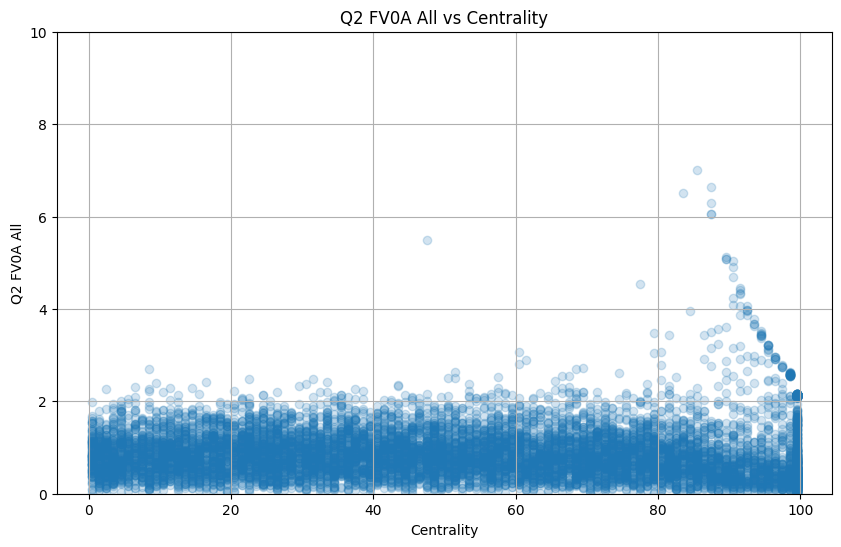

In [21]:
# Plot q2 TPC all vs cent
import numpy as np
plt.figure(figsize=(10, 6))
tpc_red_q = np.sqrt(df_after_mod["O2qvectorsfv0a"]["O2qvectorsfv0a__fQvecFV0ARe"]**2 + df_after_mod["O2qvectorsfv0a"]["O2qvectorsfv0a__fQvecFV0AIm"]**2)
plt.scatter(df_after_mod["O2qvectordevs"]["O2qvectordevs__fCent"], tpc_red_q, alpha=0.2)
plt.xlabel("Centrality")
plt.ylabel("Q2 FV0A All")
plt.title("Q2 FV0A All vs Centrality")
plt.grid()
# Set Y axis limits to focus on the region of interest
plt.ylim(0, 10)
plt.show()

In [22]:
df_after_mod["O2qvectorsft0cvec"][0:2]

,O2qvectorsft0cvec__fIsCalibrated,O2qvectorsft0cvec__fQvecFT0CReVec_size,O2qvectorsft0cvec__fQvecFT0CReVec,O2qvectorsft0cvec__fQvecFT0CImVec_size,O2qvectorsft0cvec__fQvecFT0CImVec,O2qvectorsft0cvec__fSumAmplFT0C
0,True,2,"[-0.7456824779510498, -0.7608748078346252]",2,"[-0.28628969192504883, -0.46533313393592834]",2902.729980
1,True,2,"[-0.355981707572937, 0.269896537065506]",2,"[-0.5560075044631958, 0.6266868710517883]",167.838058


In [23]:
import numpy as np

def dataframes_close(df1, df2, rtol=1e-5, atol=1e-8):

    if df1.shape != df2.shape:
        return False

    for col in df1.columns:
        s1 = df1[col]
        s2 = df2[col]

        # float columns → tolerance comparison
        if np.issubdtype(s1.dtype, np.floating):
            if not np.allclose(s1, s2, rtol=rtol, atol=atol, equal_nan=True):
                # Print 5 examples of differences
                diff_mask = ~np.isclose(s1, s2, rtol=rtol, atol=atol, equal_nan=True)
                print(f"Column '{col}' has {diff_mask.sum()} differing values. Examples:")
                print(pd.DataFrame({"before": s1[diff_mask], "after": s2[diff_mask]}).head())
                return False

        # everything else → exact
        else:
            if not s1.equals(s2):
                return False

    return True

In [24]:
for table in tables_qvec:
    if table in df_before_mod and table in df_after_mod:
        
        if dataframes_close(df_before_mod[table], df_after_mod[table]):
            print(f"The DataFrames for {table} are identical within tolerance.")
        else:
            print(f"The DataFrames for {table} are different.")
    
    else:
        print(f"Table {table} is missing in one of the DataFrames.")

The DataFrames for O2qvectordevs are different.
Column 'O2qvectorsft0c__fQvecFT0CRe' has 246 differing values. Examples:
        before        after
16  1159.95459 -1159.876831
43  1159.95459 -1159.876831
46  1159.95459 -1159.876831
57  1159.95459 -1159.876831
63  1159.95459 -1159.876831
The DataFrames for O2qvectorsft0c are different.
Column 'O2qvectorsft0a__fQvecFT0ARe' has 191 differing values. Examples:
       before        after
3    0.001693 -2412.230957
50   0.003804 -2051.431885
285 -0.001992 -1655.370850
309 -0.001992 -1655.370850
408 -0.001992 -1655.370850
The DataFrames for O2qvectorsft0a are different.
Column 'O2qvectorsft0m__fQvecFT0MRe' has 2 differing values. Examples:
           before        after
4971    -0.000335    -0.000335
5589  2121.606934 -2121.581543
The DataFrames for O2qvectorsft0m are different.
Column 'O2qvectorsfv0a__fQvecFV0ARe' has 33 differing values. Examples:
          before        after
286    -1.473825 -2082.925781
452    -1.414154 -2082.925781
569

In [25]:
# Check the differences for O2qvectorsft0c
print("Comparing O2qvectorsft0c between before and after modifications:")
if "O2qvectorsft0c" in df_before_mod and "O2qvectorsft0c" in df_after_mod:
    comparison = df_before_mod["O2qvectorsft0c"].compare(df_after_mod["O2qvectorsft0c"])
    print(comparison)
else:
    print("O2qvectorsft0c is missing in one of the DataFrames.")

Comparing O2qvectorsft0c between before and after modifications:
      O2qvectorsft0c__fQvecFT0CRe           O2qvectorsft0c__fQvecFT0CIm  \
                             self     other                        self   
0                       -0.745683 -0.745682                   -0.286290   
2                             NaN       NaN                    0.776392   
4                        0.357029  0.357029                         NaN   
7                             NaN       NaN                   -0.770572   
12                            NaN       NaN                   -1.376855   
...                           ...       ...                         ...   
10915                    0.954201  0.954201                    0.224567   
10918                    0.073102  0.073102                         NaN   
10919                    0.189057  0.189057                         NaN   
10921                    0.962092  0.962092                         NaN   
10922                         NaN  